In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


 **Chargement & exploration brute**

In [24]:
df = pd.read_csv('/content/vols_sample.csv')

print("=" * 50)
print("EXPLORATION DU DATASET")
print("=" * 50)
print(f"\n📦 Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n📋 Colonnes :\n{df.columns.tolist()}")
print(f"\n🔍 Types de données :\n{df.dtypes}")
print(f"\n Aperçu :")
df.head(3)

EXPLORATION DU DATASET

📦 Shape : 50,000 lignes × 32 colonnes

📋 Colonnes :
['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']

🔍 Types de données :
FL_DATE                     object
AIRLINE                     object
AIRLINE_DOT                 object
AIRLINE_CODE                object
DOT_CODE                     int64
FL_NUMBER                    int64
ORIGIN                      object
ORIGIN_CITY                 object
DEST                        object
DEST_CITY                   object
CRS_DEP_TIME                 int64
DEP_TIME                   float64
DEP_DELAY  

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2021-05-04,JetBlue Airways,JetBlue Airways: B6,B6,20409,384,MCO,"Orlando, FL",JFK,"New York, NY",...,0.0,159.0,152.0,129.0,944.0,NaN,NaN,NaN,NaN,NaN
1,2019-11-26,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,705,FLL,"Fort Lauderdale, FL",DTW,"Detroit, MI",...,0.0,180.0,169.0,150.0,1127.0,NaN,NaN,NaN,NaN,NaN
2,2023-06-18,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1926,SMF,"Sacramento, CA",LAS,"Las Vegas, NV",...,0.0,80.0,73.0,59.0,397.0,NaN,NaN,NaN,NaN,NaN


**Valeurs manquantes**

VALEURS MANQUANTES
                    Colonne  NaN count  NaN %
21        CANCELLATION_CODE      48723   97.4
31  DELAY_DUE_LATE_AIRCRAFT      41062   82.1
27        DELAY_DUE_CARRIER      41062   82.1
30       DELAY_DUE_SECURITY      41062   82.1
29            DELAY_DUE_NAS      41062   82.1
28        DELAY_DUE_WEATHER      41062   82.1
19                ARR_DELAY       1401    2.8
24             ELAPSED_TIME       1401    2.8
25                 AIR_TIME       1401    2.8
15                WHEELS_ON       1293    2.6
18                 ARR_TIME       1293    2.6
16                  TAXI_IN       1293    2.6
14               WHEELS_OFF       1267    2.5
13                 TAXI_OUT       1267    2.5
11                 DEP_TIME       1249    2.5
12                DEP_DELAY       1249    2.5


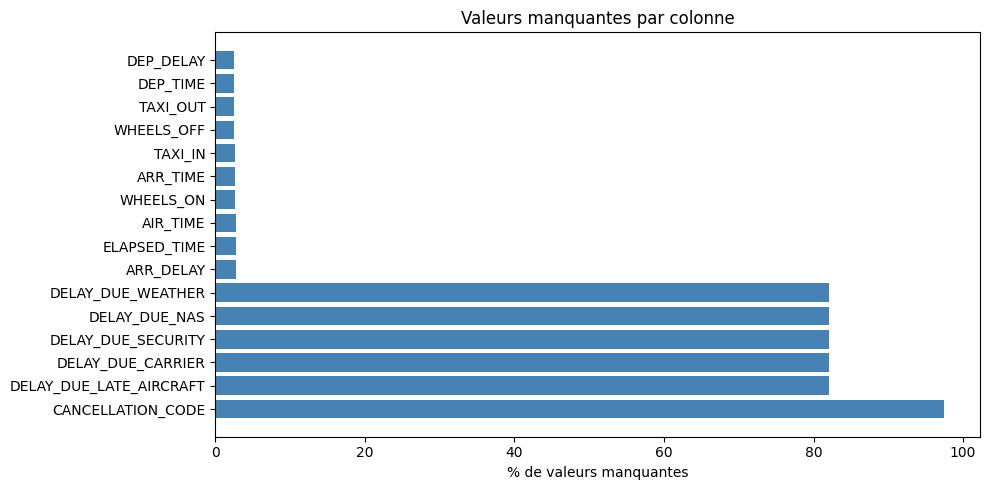

In [25]:
print("=" * 50)
print("VALEURS MANQUANTES")
print("=" * 50)

nan_df = pd.DataFrame({
    'Colonne': df.columns,
    'NaN count': df.isnull().sum().values,
    'NaN %': (df.isnull().sum() / len(df) * 100).round(1).values
}).sort_values('NaN %', ascending=False)

print(nan_df[nan_df['NaN %'] > 0].to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
cols_nan = nan_df[nan_df['NaN %'] > 0]
ax.barh(cols_nan['Colonne'], cols_nan['NaN %'], color='steelblue')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne')
plt.tight_layout()
plt.show()

**Nettoyage**

In [26]:
print("=" * 50)
print("NETTOYAGE DES DONNÉES")
print("=" * 50)

# 1. Supprimer colonnes inutiles (trop de NaN ou data leakage)
cols_to_drop = [
    'CANCELLATION_CODE',     # 97% NaN
    'DELAY_DUE_CARRIER',     # 82% NaN + data leakage
    'DELAY_DUE_WEATHER',     # 82% NaN + data leakage
    'DELAY_DUE_NAS',         # 82% NaN + data leakage
    'DELAY_DUE_SECURITY',    # 82% NaN + data leakage
    'DELAY_DUE_LATE_AIRCRAFT', # 82% NaN + data leakage
    'AIRLINE_DOT',           # doublon de AIRLINE
    'DOT_CODE',              # identifiant technique inutile
    'FL_NUMBER',             # numéro de vol non informatif
    'WHEELS_OFF', 'WHEELS_ON', # data leakage (info pendant le vol)
    'ELAPSED_TIME', 'AIR_TIME', # data leakage
    'TAXI_OUT', 'TAXI_IN',   # data leakage
    'DEP_TIME', 'ARR_TIME',  # data leakage
]
df = df.drop(columns=cols_to_drop)
print(f"✅ Colonnes supprimées : {len(cols_to_drop)}")
print(f"   Shape après suppression : {df.shape}")

# 2. Supprimer vols annulés (ARR_DELAY NaN = vol annulé)
before = len(df)
df = df.dropna(subset=['ARR_DELAY'])
print(f"\n✅ Vols annulés supprimés : {before - len(df)}")
print(f"   Shape après suppression : {df.shape}")

# 3. Supprimer NaN restants (DEP_DELAY)
before = len(df)
df = df.dropna(subset=['DEP_DELAY'])
print(f"\n✅ NaN DEP_DELAY supprimés : {before - len(df)}")
print(f"   Shape finale : {df.shape}")

# 4. Créer variable cible RETARDE (1 si ARR_DELAY > 15 min)
df['RETARDE'] = (df['ARR_DELAY'] > 15).astype(int)
print(f"\n✅ Variable cible créée :")
print(f"   Non retardé (0) : {(df['RETARDE']==0).sum():,} ({(df['RETARDE']==0).mean()*100:.1f}%)")
print(f"   Retardé    (1) : {(df['RETARDE']==1).sum():,} ({(df['RETARDE']==1).mean()*100:.1f}%)")

# 5. Parser la date
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH']   = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek  # 0=Lundi, 6=Dimanche
df['HOUR_DEP'] = (df['CRS_DEP_TIME'] // 100).astype(int)
print(f"\n✅ Features temporelles créées : MONTH, DAY_OF_WEEK, HOUR_DEP")

print(f"\n✅ Dataset nettoyé : {df.shape}")
df.head(3)

NETTOYAGE DES DONNÉES
✅ Colonnes supprimées : 17
   Shape après suppression : (50000, 15)

✅ Vols annulés supprimés : 1401
   Shape après suppression : (48599, 15)

✅ NaN DEP_DELAY supprimés : 0
   Shape finale : (48599, 15)

✅ Variable cible créée :
   Non retardé (0) : 39,958 (82.2%)
   Retardé    (1) : 8,641 (17.8%)

✅ Features temporelles créées : MONTH, DAY_OF_WEEK, HOUR_DEP

✅ Dataset nettoyé : (48599, 19)


,FL_DATE,AIRLINE,AIRLINE_CODE,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_DELAY,CRS_ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,RETARDE,MONTH,DAY_OF_WEEK,HOUR_DEP
0,2021-05-04,JetBlue Airways,B6,MCO,"Orlando, FL",JFK,"New York, NY",1551,7.0,1830,0.0,0.0,0.0,159.0,944.0,0,5,1,15
1,2019-11-26,Delta Air Lines Inc.,DL,FLL,"Fort Lauderdale, FL",DTW,"Detroit, MI",800,-5.0,1100,-16.0,0.0,0.0,180.0,1127.0,0,11,1,8
2,2023-06-18,Southwest Airlines Co.,WN,SMF,"Sacramento, CA",LAS,"Las Vegas, NV",2155,-4.0,2315,-11.0,0.0,0.0,80.0,397.0,0,6,6,21


In [27]:
print("=" * 50)
print("SUPPRESSION DES OUTLIERS")
print("=" * 50)

before = len(df)

# Seuils réalistes
df = df[
    (df['ARR_DELAY'] >= -60) & (df['ARR_DELAY'] <= 600) &
    (df['DEP_DELAY'] >= -40) & (df['DEP_DELAY'] <= 600)
]

removed = before - len(df)
print(f"✅ Outliers supprimés : {removed} vols ({removed/before*100:.2f}%)")
print(f"✅ Dataset final : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

# Vérification
print(f"\nARR_DELAY — min: {df['ARR_DELAY'].min()} | max: {df['ARR_DELAY'].max()}")
print(f"DEP_DELAY — min: {df['DEP_DELAY'].min()} | max: {df['DEP_DELAY'].max()}")

SUPPRESSION DES OUTLIERS
✅ Outliers supprimés : 63 vols (0.13%)
✅ Dataset final : 48,536 lignes × 19 colonnes

ARR_DELAY — min: -59.0 | max: 576.0
DEP_DELAY — min: -40.0 | max: 569.0


In [28]:
print("=" * 50)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 50)

print("\n📊 Variables numériques :")
print(df[['ARR_DELAY','DEP_DELAY','DISTANCE','CRS_ELAPSED_TIME']].describe().round(2))

print("\n✈️ Top 5 compagnies :")
print(df['AIRLINE'].value_counts().head(5))

print("\n🛫 Top 10 aéroports de départ :")
print(df['ORIGIN'].value_counts().head(10))

print("\n📅 Répartition par année :")
print(df['FL_DATE'].dt.year.value_counts().sort_index())

STATISTIQUES DESCRIPTIVES

📊 Variables numériques :
       ARR_DELAY  DEP_DELAY  DISTANCE  CRS_ELAPSED_TIME
count   48536.00   48536.00  48536.00          48536.00
mean        3.11       8.83    809.97            142.31
std        39.82      37.09    588.56             71.60
min       -59.00     -40.00     30.00             20.00
25%       -16.00      -6.00    384.00             90.00
50%        -7.00      -2.00    653.00            125.00
75%         7.00       6.00   1044.00            172.00
max       576.00     569.00   5095.00            695.00

✈️ Top 5 compagnies :
AIRLINE
Southwest Airlines Co.    9204
Delta Air Lines Inc.      6382
American Airlines Inc.    6336
SkyWest Airlines Inc.     5653
United Air Lines Inc.     4014
Name: count, dtype: int64

🛫 Top 10 aéroports de départ :
ORIGIN
ATL    2493
DFW    2152
ORD    1995
DEN    1949
CLT    1524
LAX    1312
PHX    1193
SEA    1190
LAS    1187
MCO    1114
Name: count, dtype: int64

📅 Répartition par année :
FL_DATE
2019    1232

**Distribution variable cible**

EDA — DISTRIBUTION VARIABLE CIBLE


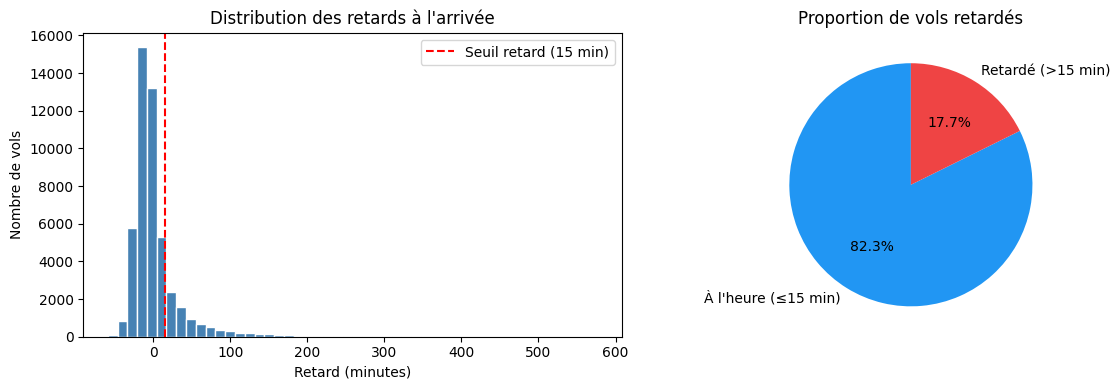


✅ Vols à l'heure  : 39,949 (82.3%)
✅ Vols retardés   : 8,587 (17.7%)


In [29]:
print("=" * 50)
print("EDA — DISTRIBUTION VARIABLE CIBLE")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution ARR_DELAY
axes[0].hist(df['ARR_DELAY'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=15, color='red', linestyle='--', label='Seuil retard (15 min)')
axes[0].set_title('Distribution des retards à l\'arrivée')
axes[0].set_xlabel('Retard (minutes)')
axes[0].set_ylabel('Nombre de vols')
axes[0].legend()

# Pie chart RETARDE
labels = ['À l\'heure (≤15 min)', 'Retardé (>15 min)']
sizes  = [df['RETARDE'].value_counts()[0], df['RETARDE'].value_counts()[1]]
colors = ['#2196F3', '#EF4444']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion de vols retardés')

plt.tight_layout()
plt.show()

print(f"\n✅ Vols à l'heure  : {sizes[0]:,} ({sizes[0]/len(df)*100:.1f}%)")
print(f"✅ Vols retardés   : {sizes[1]:,} ({sizes[1]/len(df)*100:.1f}%)")

**Retards par compagnie**

EDA — RETARDS PAR COMPAGNIE


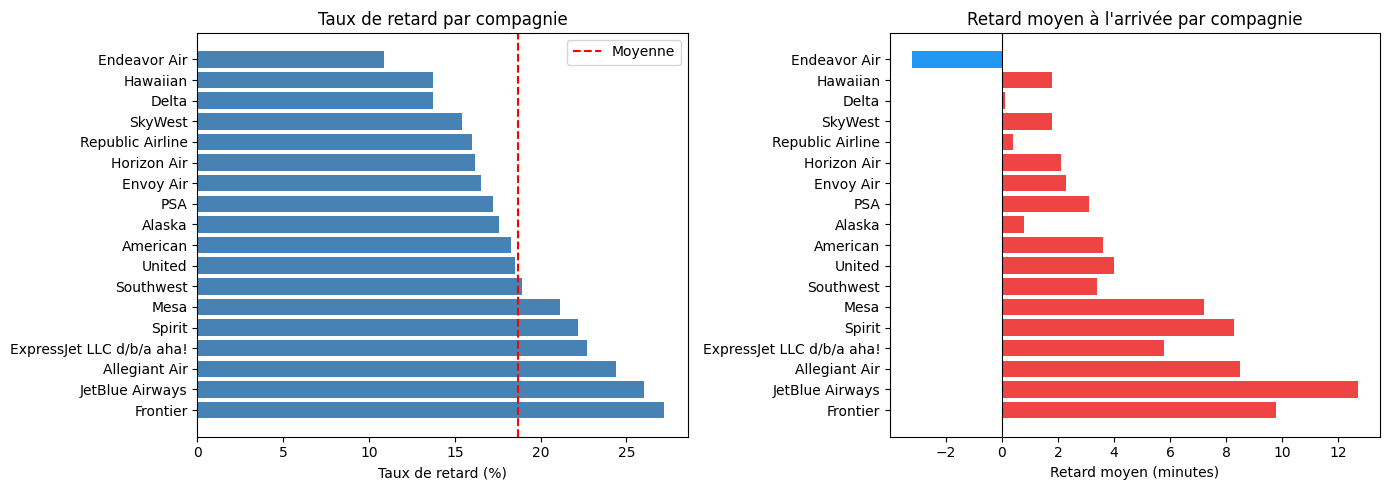

                AIRLINE_SHORT  total_vols  taux_retard  retard_moyen
7                    Frontier        1029         27.2           9.8
10            JetBlue Airways        1874         26.0          12.7
1               Allegiant Air         853         24.4           8.5
6   ExpressJet LLC d/b/a aha!         308         22.7           5.8
16                     Spirit        1565         22.2           8.3
11                       Mesa         997         21.1           7.2
15                  Southwest        9204         18.9           3.4
17                     United        4014         18.5           4.0
2                    American        6336         18.3           3.6
0                      Alaska        1737         17.6           0.8
12                        PSA        1668         17.2           3.1
5                   Envoy Air        1969         16.5           2.3
9                 Horizon Air         315         16.2           2.1
13           Republic Airline     

In [30]:
print("=" * 50)
print("EDA — RETARDS PAR COMPAGNIE")
print("=" * 50)

airline_stats = df.groupby('AIRLINE').agg(
    total_vols=('RETARDE', 'count'),
    taux_retard=('RETARDE', 'mean'),
    retard_moyen=('ARR_DELAY', 'mean')
).reset_index()
airline_stats['taux_retard'] = (airline_stats['taux_retard'] * 100).round(1)
airline_stats['retard_moyen'] = airline_stats['retard_moyen'].round(1)
airline_stats = airline_stats.sort_values('taux_retard', ascending=False)

# Raccourcir les noms
airline_stats['AIRLINE_SHORT'] = airline_stats['AIRLINE'].str.replace(
    ' Airlines', '').str.replace(' Air Lines', '').str.replace(
    ' Inc.', '').str.replace(' Co.', '').str.strip()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de retard
axes[0].barh(airline_stats['AIRLINE_SHORT'], airline_stats['taux_retard'],
             color='steelblue')
axes[0].set_xlabel('Taux de retard (%)')
axes[0].set_title('Taux de retard par compagnie')
axes[0].axvline(x=airline_stats['taux_retard'].mean(),
                color='red', linestyle='--', label='Moyenne')
axes[0].legend()

# Retard moyen
colors = ['#EF4444' if x > 0 else '#2196F3'
          for x in airline_stats['retard_moyen']]
axes[1].barh(airline_stats['AIRLINE_SHORT'], airline_stats['retard_moyen'],
             color=colors)
axes[1].set_xlabel('Retard moyen (minutes)')
axes[1].set_title('Retard moyen à l\'arrivée par compagnie')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print(airline_stats[['AIRLINE_SHORT','total_vols',
                      'taux_retard','retard_moyen']].to_string())

**Retards par heure et par mois**

EDA — RETARDS PAR HEURE ET PAR MOIS


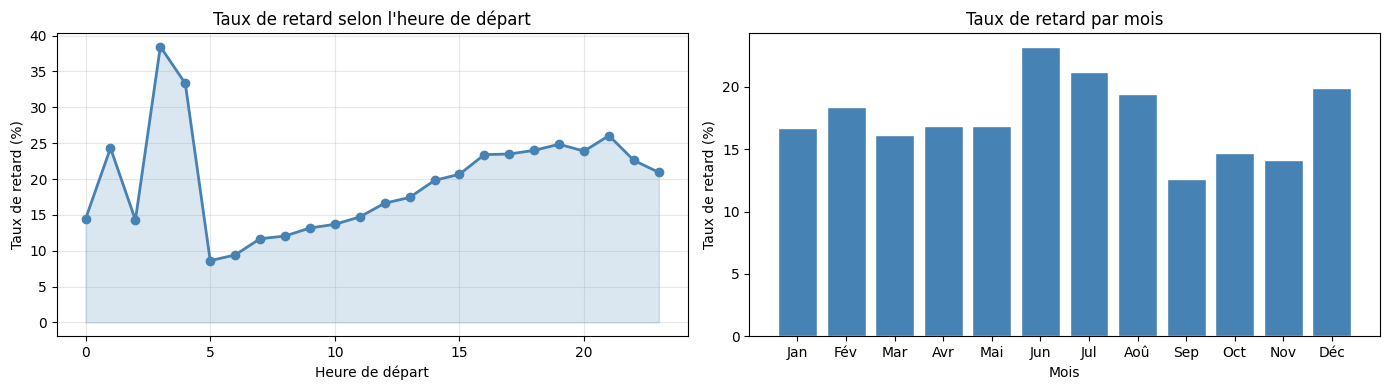

In [31]:
print("=" * 50)
print("EDA — RETARDS PAR HEURE ET PAR MOIS")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Par heure de départ
hour_stats = df.groupby('HOUR_DEP')['RETARDE'].mean().reset_index()
hour_stats['taux'] = hour_stats['RETARDE'] * 100
axes[0].plot(hour_stats['HOUR_DEP'], hour_stats['taux'],
             'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].fill_between(hour_stats['HOUR_DEP'], hour_stats['taux'],
                     alpha=0.2, color='steelblue')
axes[0].set_xlabel('Heure de départ')
axes[0].set_ylabel('Taux de retard (%)')
axes[0].set_title('Taux de retard selon l\'heure de départ')
axes[0].grid(True, alpha=0.3)

# Par mois
month_stats = df.groupby('MONTH')['RETARDE'].mean().reset_index()
month_stats['taux'] = month_stats['RETARDE'] * 100
mois = ['Jan','Fév','Mar','Avr','Mai','Jun',
        'Jul','Aoû','Sep','Oct','Nov','Déc']
month_stats['mois_label'] = month_stats['MONTH'].apply(
    lambda x: mois[x-1] if x <= 12 else str(x))
axes[1].bar(month_stats['mois_label'], month_stats['taux'],
            color='steelblue', edgecolor='white')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Taux de retard (%)')
axes[1].set_title('Taux de retard par mois')

plt.tight_layout()
plt.show()

**Corrélations**

EDA — MATRICE DE CORRÉLATIONS


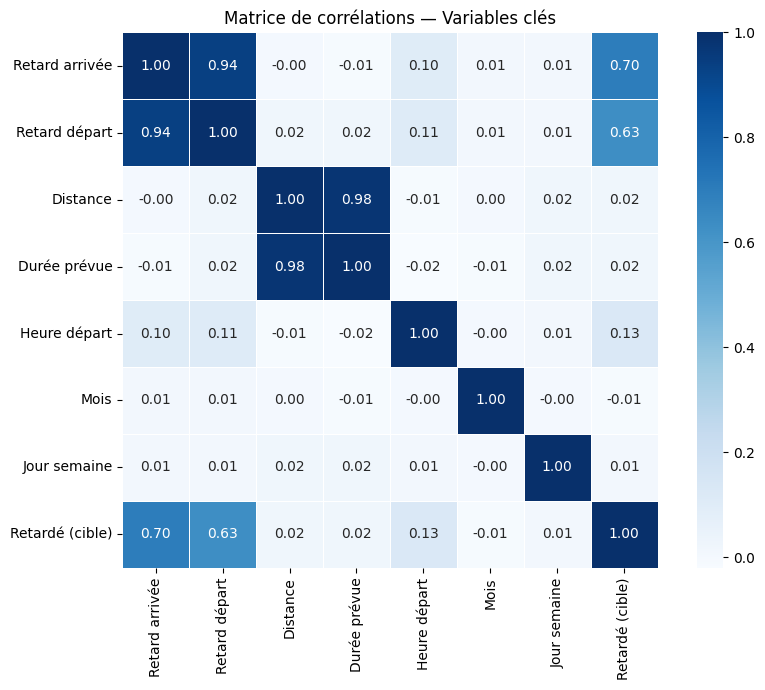


💡 Observations :
- DEP_DELAY est fortement corrélé à ARR_DELAY → feature clé
- DISTANCE peu corrélé → la distance n'explique pas les retards


In [32]:
print("=" * 50)
print("EDA — MATRICE DE CORRÉLATIONS")
print("=" * 50)

corr_cols = ['ARR_DELAY', 'DEP_DELAY', 'DISTANCE',
             'CRS_ELAPSED_TIME', 'HOUR_DEP', 'MONTH',
             'DAY_OF_WEEK', 'RETARDE']
corr_labels = ['Retard arrivée', 'Retard départ', 'Distance',
               'Durée prévue', 'Heure départ', 'Mois',
               'Jour semaine', 'Retardé (cible)']

corr_matrix = df[corr_cols].corr().round(2)
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues',
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de corrélations — Variables clés')
plt.tight_layout()
plt.show()

print("\n💡 Observations :")
print("- DEP_DELAY est fortement corrélé à ARR_DELAY → feature clé")
print("- DISTANCE peu corrélé → la distance n'explique pas les retards")

**Feature Engineering**

In [33]:
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# 1. Encodage variables catégorielles
le_airline = LabelEncoder()
le_origin  = LabelEncoder()
le_dest    = LabelEncoder()

df['AIRLINE_ENC'] = le_airline.fit_transform(df['AIRLINE'])
df['ORIGIN_ENC']  = le_origin.fit_transform(df['ORIGIN'])
df['DEST_ENC']    = le_dest.fit_transform(df['DEST'])

print("✅ Encodage compagnies, origines, destinations")

# 2. Feature : heure de la journée (4 tranches)
def tranche_horaire(h):
    if h < 6:   return 0  # Nuit
    if h < 12:  return 1  # Matin
    if h < 18:  return 2  # Après-midi
    return 3              # Soir

df['TRANCHE_HORAIRE'] = df['HOUR_DEP'].apply(tranche_horaire)
print("✅ TRANCHE_HORAIRE : 0=Nuit, 1=Matin, 2=Après-midi, 3=Soir")

# 3. Feature : week-end
df['IS_WEEKEND'] = (df['DAY_OF_WEEK'] >= 5).astype(int)
print("✅ IS_WEEKEND : 1 si samedi ou dimanche")

# 4. Feature : saison
def saison(m):
    if m in [12, 1, 2]:  return 0  # Hiver
    if m in [3, 4, 5]:   return 1  # Printemps
    if m in [6, 7, 8]:   return 2  # Été
    return 3                        # Automne

df['SAISON'] = df['MONTH'].apply(saison)
print("✅ SAISON : 0=Hiver, 1=Printemps, 2=Été, 3=Automne")

# 5. Feature : vol long courrier
df['LONG_COURRIER'] = (df['DISTANCE'] > 1500).astype(int)
print("✅ LONG_COURRIER : 1 si distance > 1500 miles")

# 6. Features finales pour le modèle
FEATURES = [
    'DEP_DELAY',          # ⭐ Feature la plus importante
    'AIRLINE_ENC',        # Compagnie aérienne
    'ORIGIN_ENC',         # Aéroport de départ
    'DEST_ENC',           # Aéroport d'arrivée
    'DISTANCE',           # Distance du vol
    'CRS_ELAPSED_TIME',   # Durée prévue
    'HOUR_DEP',           # Heure de départ
    'TRANCHE_HORAIRE',    # Tranche horaire
    'DAY_OF_WEEK',        # Jour de la semaine
    'IS_WEEKEND',         # Week-end ou non
    'MONTH',              # Mois
    'SAISON',             # Saison
    'LONG_COURRIER',      # Long ou court courrier
]

print(f"\n✅ {len(FEATURES)} features sélectionnées")
print(f"✅ Variable cible : RETARDE")

# Vérification
print(f"\nDataset final : {df.shape}")
print(f"NaN dans features : {df[FEATURES].isnull().sum().sum()}")

FEATURE ENGINEERING
✅ Encodage compagnies, origines, destinations
✅ TRANCHE_HORAIRE : 0=Nuit, 1=Matin, 2=Après-midi, 3=Soir
✅ IS_WEEKEND : 1 si samedi ou dimanche
✅ SAISON : 0=Hiver, 1=Printemps, 2=Été, 3=Automne
✅ LONG_COURRIER : 1 si distance > 1500 miles

✅ 13 features sélectionnées
✅ Variable cible : RETARDE

Dataset final : (48536, 26)
NaN dans features : 0


**Entraînement du modèle**

In [34]:
print("=" * 50)
print("ENTRAÎNEMENT DU MODÈLE ML")
print("=" * 50)

X = df[FEATURES]
y = df['RETARDE']

# Split train/test — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Train : {X_train.shape[0]:,} vols")
print(f"✅ Test  : {X_test.shape[0]:,} vols")
print(f"✅ Proportion retardés train : {y_train.mean()*100:.1f}%")
print(f"✅ Proportion retardés test  : {y_test.mean()*100:.1f}%")

# Random Forest
print("\n⏳ Entraînement Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Évaluation
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n📊 RÉSULTATS :")
print(classification_report(y_test, y_pred,
      target_names=['À l\'heure', 'Retardé']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")

ENTRAÎNEMENT DU MODÈLE ML
✅ Train : 38,828 vols
✅ Test  : 9,708 vols
✅ Proportion retardés train : 17.7%
✅ Proportion retardés test  : 17.7%

⏳ Entraînement Random Forest...

📊 RÉSULTATS :
              precision    recall  f1-score   support

   À l'heure       0.94      0.99      0.96      7990
     Retardé       0.92      0.69      0.79      1718

    accuracy                           0.93      9708
   macro avg       0.93      0.84      0.87      9708
weighted avg       0.93      0.93      0.93      9708

AUC-ROC : 0.9130


**Feature importance + sauvegarde**

FEATURE IMPORTANCE & SAUVEGARDE


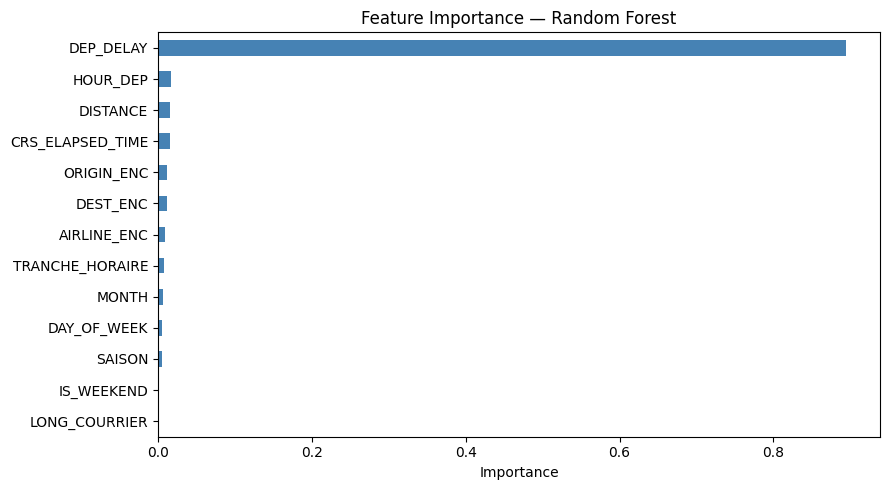

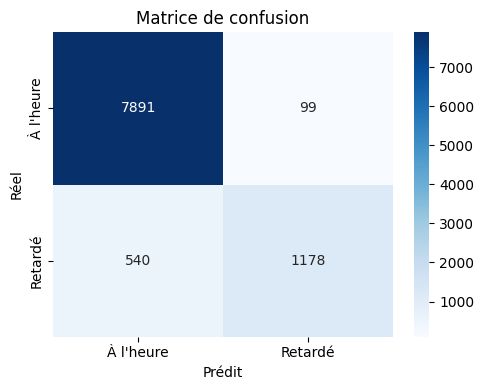

 Modèle sauvegardé : models/random_forest.pkl
 Encodeurs sauvegardés
 Infos modèle sauvegardées : models/model_info.json

🎯 Accuracy : 0.9342
🎯 AUC-ROC  : 0.9130


In [35]:
print("=" * 50)
print("FEATURE IMPORTANCE & SAUVEGARDE")
print("=" * 50)

# Feature importance
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
fi.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['À l\'heure','Retardé'],
            yticklabels=['À l\'heure','Retardé'])
ax.set_title('Matrice de confusion')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()

# Sauvegarde
import os
os.makedirs('models', exist_ok=True)
joblib.dump(rf, 'models/random_forest.pkl')
joblib.dump(le_airline, 'models/le_airline.pkl')
joblib.dump(le_origin,  'models/le_origin.pkl')
joblib.dump(le_dest,    'models/le_dest.pkl')

import json
model_info = {
    'features': FEATURES,
    'airlines': le_airline.classes_.tolist(),
    'origins':  le_origin.classes_.tolist(),
    'dests':    le_dest.classes_.tolist(),
    'accuracy': round(float((y_pred == y_test).mean()), 4),
    'auc':      round(float(roc_auc_score(y_test, y_proba)), 4)
}
with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f)

print(" Modèle sauvegardé : models/random_forest.pkl")
print(" Encodeurs sauvegardés")
print(" Infos modèle sauvegardées : models/model_info.json")
print(f"\n🎯 Accuracy : {model_info['accuracy']:.4f}")
print(f"🎯 AUC-ROC  : {model_info['auc']:.4f}")